In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, roc_auc_score, roc_curve)
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported!")

All libraries imported!


In [5]:
train_df = pd.read_csv('../data/processed/train_data.csv')
test_df = pd.read_csv('../data/processed/test_data.csv')

X_train = train_df.drop('Risk', axis=1)
y_train = train_df['Risk']

X_test = test_df.drop('Risk', axis=1)
y_test = test_df['Risk']

print("=== Data Loaded ===")
print(f"Train: {X_train.shape}")
print(f"Test : {X_test.shape}")
print(f"\nTrain Class Distribution:")
print(y_train.value_counts())

=== Data Loaded ===
Train: (836, 9)
Test : (200, 9)

Train Class Distribution:
Risk
1    418
0    418
Name: count, dtype: int64


In [3]:
print("Training Logistic Regression...")

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

lr_auc = roc_auc_score(y_test, lr_prob)
lr_acc = accuracy_score(y_test, lr_pred)

print(f"Logistic Regression Results:")
print(f"Accuracy : {lr_acc:.4f}")
print(f"AUC Score: {lr_auc:.4f}")

Training Logistic Regression...
Logistic Regression Results:
Accuracy : 0.9250
AUC Score: 0.9818


In [6]:
print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(y_test, rf_prob)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Random Forest Results:")
print(f"Accuracy : {rf_acc:.4f}")
print(f"AUC Score: {rf_auc:.4f}")

Training Random Forest...
Random Forest Results:
Accuracy : 0.9550
AUC Score: 0.9948


In [7]:
print("Training XGBoost...")

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

xgb_auc = roc_auc_score(y_test, xgb_prob)
xgb_acc = accuracy_score(y_test, xgb_pred)

print(f"XGBoost Results:")
print(f"Accuracy : {xgb_acc:.4f}")
print(f"AUC Score: {xgb_auc:.4f}")

Training XGBoost...
XGBoost Results:
Accuracy : 0.9700
AUC Score: 0.9970


=== Model Comparison ===
              Model  Accuracy  AUC Score
Logistic Regression     0.925   0.981771
      Random Forest     0.955   0.994792
            XGBoost     0.970   0.996995


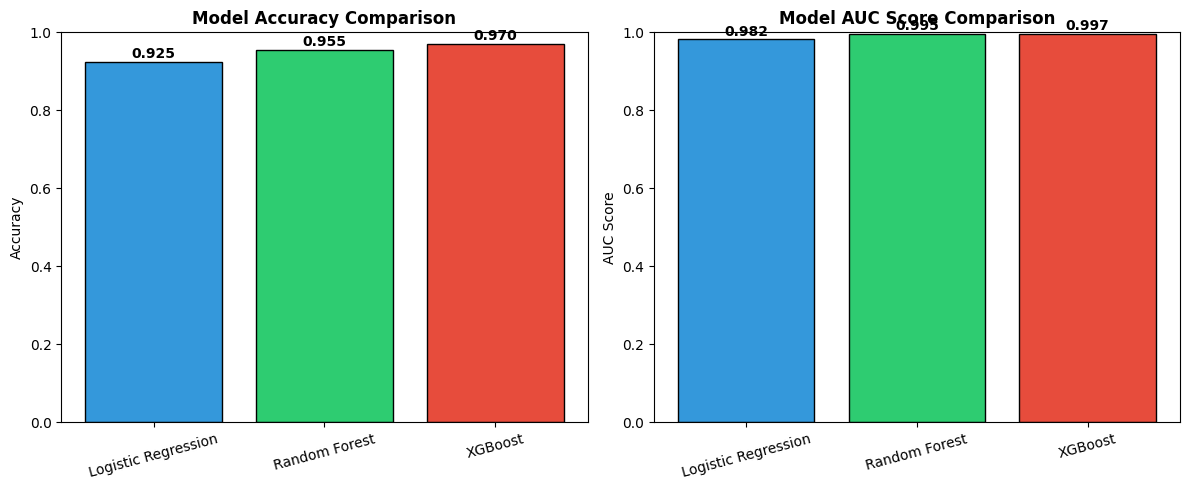

In [8]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [lr_acc, rf_acc, xgb_acc],
    'AUC Score': [lr_auc, rf_auc, xgb_auc]
})

print("=== Model Comparison ===")
print(results.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy
axes[0].bar(results['Model'], results['Accuracy'],
            color=['#3498db', '#2ecc71', '#e74c3c'],
            edgecolor='black')
axes[0].set_title('Model Accuracy Comparison', fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
for i, v in enumerate(results['Accuracy']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# AUC
axes[1].bar(results['Model'], results['AUC Score'],
            color=['#3498db', '#2ecc71', '#e74c3c'],
            edgecolor='black')
axes[1].set_title('Model AUC Score Comparison', fontweight='bold')
axes[1].set_ylabel('AUC Score')
axes[1].set_ylim(0, 1)
for i, v in enumerate(results['AUC Score']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

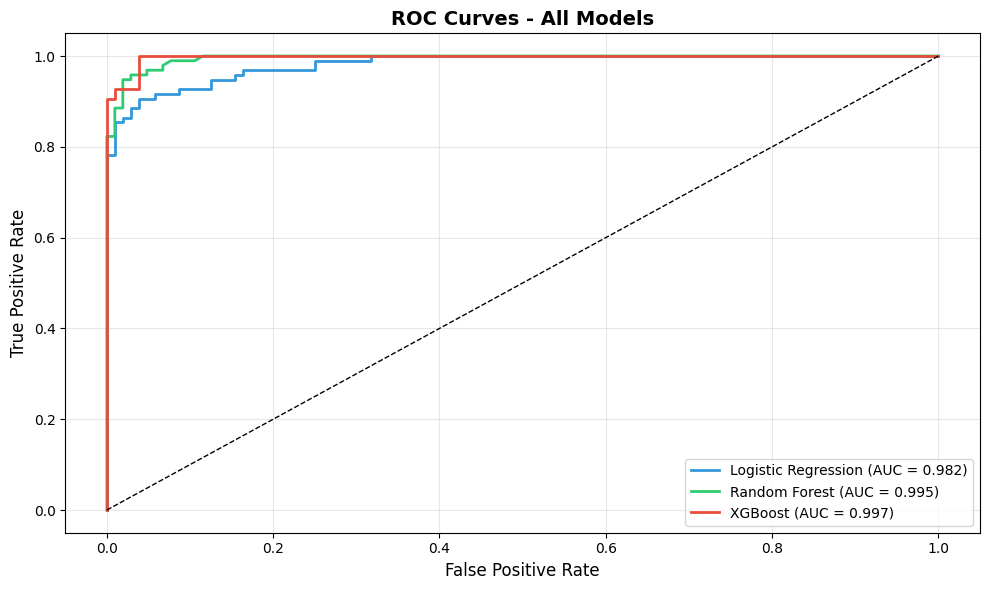

In [9]:
plt.figure(figsize=(10, 6))

models = {
    'Logistic Regression': lr_prob,
    'Random Forest': rf_prob,
    'XGBoost': xgb_prob
}
colors = ['#3498db', '#2ecc71', '#e74c3c']

for (name, prob), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, color=color, 
             label=f'{name} (AUC = {auc:.3f})',
             linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

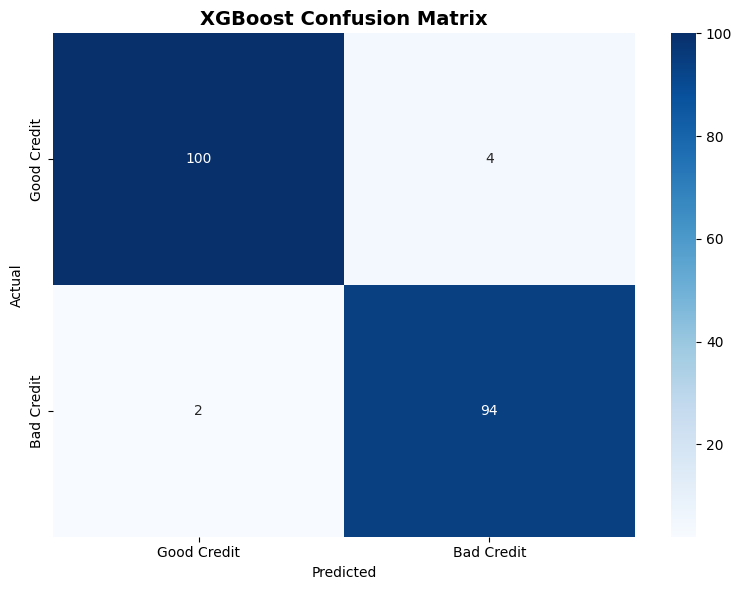


Classification Report:
              precision    recall  f1-score   support

 Good Credit       0.98      0.96      0.97       104
  Bad Credit       0.96      0.98      0.97        96

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200



In [10]:
plt.figure(figsize=(8, 6))

cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, 
            annot=True, 
            fmt='d',
            cmap='Blues',
            xticklabels=['Good Credit', 'Bad Credit'],
            yticklabels=['Good Credit', 'Bad Credit'])
plt.title('XGBoost Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred, 
      target_names=['Good Credit', 'Bad Credit']))

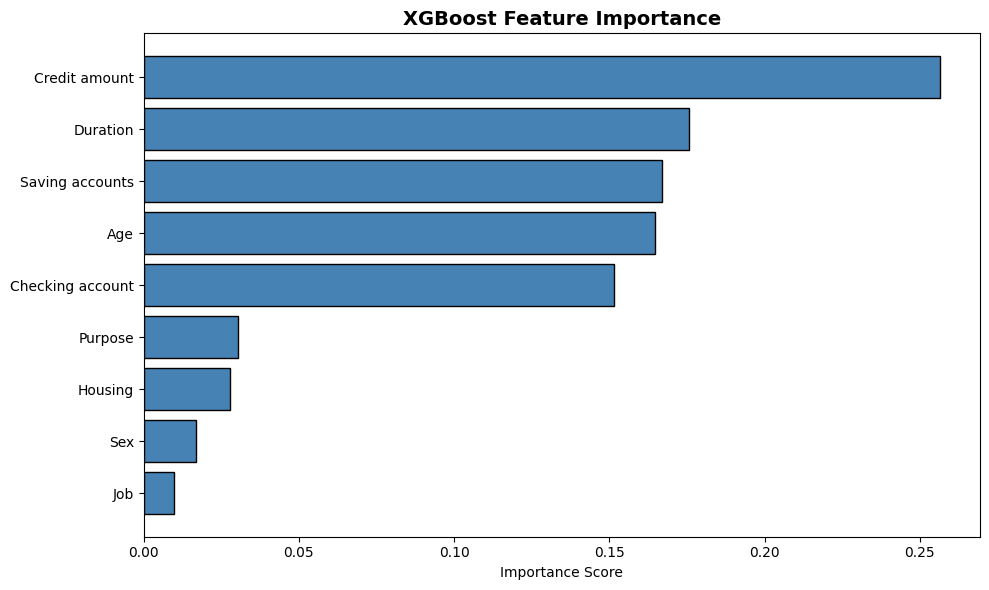

In [11]:
plt.figure(figsize=(10, 6))

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.barh(importance_df['Feature'], 
         importance_df['Importance'],
         color='steelblue',
         edgecolor='black')
plt.title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [12]:
# Save XGBoost as best model
joblib.dump(xgb_model, '../models/xgboost_model.pkl')
joblib.dump(lr_model, '../models/logistic_regression.pkl')
joblib.dump(rf_model, '../models/random_forest.pkl')

print("=== Models Saved! ===")
print("Saved to models/ folder:")
print("- xgboost_model.pkl")
print("- logistic_regression.pkl")
print("- random_forest.pkl")
print(f"\nBest Model: XGBoost")
print(f"AUC Score : {xgb_auc:.4f}")
print(f"Accuracy  : {xgb_acc:.4f}")

=== Models Saved! ===
Saved to models/ folder:
- xgboost_model.pkl
- logistic_regression.pkl
- random_forest.pkl

Best Model: XGBoost
AUC Score : 0.9970
Accuracy  : 0.9700
